In [3]:
import os, sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Basic Usage

In [4]:
from torchpenny import QLayer
import pennylane as qml
import torch

## Quantum Layer 

Next `QuantumLayer` class is a default example of **torchpenny** framework.
It is a quantum circuit without any input and internal parameters.

`QLayer` is a Pytorch `Module` class manages quantum device and `Qnode` of Pennylane. 

In [5]:
class QuantumLayer(QLayer):
    def __init__(self, *args, **kwargs):
        super(QuantumLayer, self).__init__(*args, **kwargs)
    def inner_gates(self, x=None):
        # You can define Pennylane circuit inside here.
        for w in range(self.wires):
            qml.Hadamard(wires=w)
            #qml.X(wires=w)
        qml.CNOT([0, 1])
        qml.X(wires=2)
    def measurement(self):
        return qml.probs()


The `inner_gates` and `measurement` are wrapper part of the quantum circuit. 
It is same with next function.

```.{py}
def circuit(x):
    inner_gates(x)
    return measurement()
```

In [6]:
quantum_layer = QuantumLayer(wires=3)

In [7]:
quantum_layer #

QuantumLayer[Qnode, wires=3]()

In [8]:
print(qml.draw(quantum_layer.qnode)())

0: ──H─╭●─┤  Probs
1: ──H─╰X─┤  Probs
2: ──H──X─┤  Probs


In [9]:
quantum_layer()

tensor([0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250],
       dtype=torch.float64)

The output always be a torch `Tensor`. No matter what measurement method you choose supported by Pennylane.

- `prob`
- `expval`
- `sample`

In [10]:
class QuantumLayer(QLayer):
    def __init__(self, *args, **kwargs):
        super(QuantumLayer, self).__init__(*args, **kwargs)
    def inner_gates(self, x=None):
        # You can define Pennylane circuit inside here.
        for w in range(self.wires):
            qml.Hadamard(wires=w)
            qml.X(wires=w)
        qml.CNOT([0, 1])
        qml.X(wires=2)
    def measurement(self):
        return [qml.expval(qml.PauliX(i)) for i in range(self.wires)]

In [11]:
quantum_layer = QuantumLayer(wires=3)
quantum_layer()

tensor([1.0000, 1.0000, 1.0000], dtype=torch.float64)

(<Figure size 600x400 with 1 Axes>, <Axes: >)

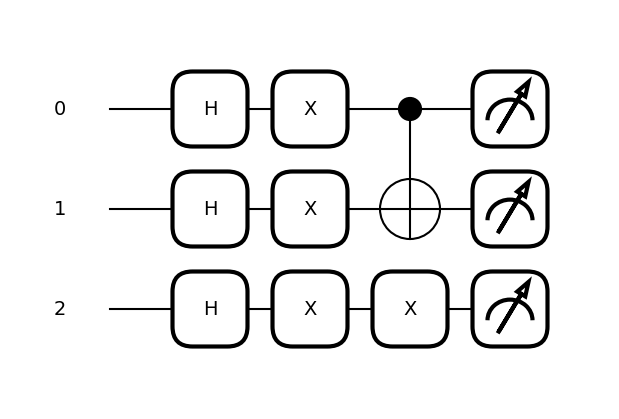

In [13]:
qml.draw_mpl(quantum_layer.qnode)()

---

## QSubLayer module

`QSubLayer` module is an alternative api of `Operation` or `Template` class of Pennylane framework. In Pennylane, `Template` class also provides a block layer of quantum gates. However, their parameters are given by user and external source. Users have to manage the parameter dimension data for each `Template` in the circuit. 

Meanwhile, in Pytorch, all `Module` class manages its own parameter automatically. The input data and inherited weight and bias are separated. To construct complicated circuit and program, this automatic management has many benefits not only for rapid prototyping but also for maintenance.

Thus, `QSubLayer` provides automatic parameter management routine based on `Moudle` class. 

For example, here is an example class `ParamGate`.

In [15]:
from torchpenny import QSubLayer

In [16]:
class ParamGate(QSubLayer):
    def __init__(self, wires:int, param_received=False):
        super(ParamGate, self).__init__(wires=wires, param_received=param_received)
    def init_weights(self):
        r = self.wires%2
        n = int(self.wires/2) + r
        return torch.rand(n).unsqueeze(0)
    def forward(self, x=None, wires=[]):
        assert len(wires) == (self.wires), "Applied wires must be matched with the defined qubit dimension."
        params = self.get_params(x)
        for i in range(self.num_params):
            w = 2*i
            qml.RX(params[:, i], wires=w)        

In [17]:
# You can choose whether the the layer receives the parameter or not.
gate =  ParamGate(wires=4, param_received=False) 
pgate = ParamGate(wires=4, param_received=True)

In [18]:
# The difference appears on repr and string representation of the instance.
print("Instances")
print("\t", gate, pgate)
print("Input tensor dimension")
print("\t", gate.input_dim, pgate.input_dim)

Instances
	 ParamGate() ParamGate[2]()
Input tensor dimension
	 None torch.Size([1, 2])


In [ ]:
# It is itself a Pennylane gate set.
dev = qml.device("default.qubit", wires= 4)
@qml.qnode(dev)
def circuit(x):
    qml.H(wires=1)
    qml.H(wires=3)
    gate(wires=range(4))
    pgate(x, wires=range(4))
    return qml.probs()

In [20]:
input_data = torch.rand(pgate.input_dim)
circuit(input_data)

tensor([[0.1671, 0.1671, 0.0344, 0.0344, 0.1671, 0.1671, 0.0344, 0.0344, 0.0402,
         0.0402, 0.0083, 0.0083, 0.0402, 0.0402, 0.0083, 0.0083]],
       dtype=torch.float64, grad_fn=<ViewBackward0>)

(<Figure size 500x500 with 1 Axes>, <Axes: >)

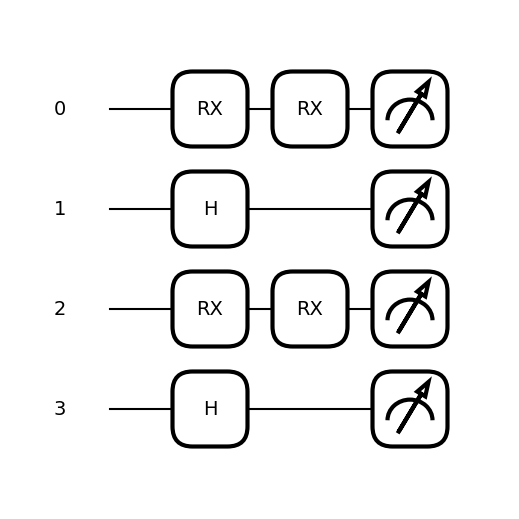

In [21]:
qml.draw_mpl(circuit)(input_data)

On `init_weights` method, it returns the weights to be used to paramerized quantum gates.
In Pytorch `Module`, the trainable parameters are defined through `Parameter` instance.
In here, the instance of `params` attribute is automatically determined by `self.param_received`, `Parameter` or `Tensor`.

**Note**: The inner trainable weights could be vary by the `QSubLayer` structrue. Therefore, `module.parameters()` values could be different with `module.params`. 
The `parameters()` returns every trainable parameters in the module, and `params` is a parameter attirbute that the module has a charge of direct management.

In next tutorial **QAOA** example, you can see the example that multi stacked `QSubLayer` example.


## Example

### Feature 

Feature is a name used in Qiskit framework. 
In here, we refer it as a quantum layer that we can assign some input parameters.

In [ ]:
class ZZfeatureMap(QSubLayer):
    entanglement_structure= [
        "full", "linear", "reverse_linear", "circular", "sca"
    ]
    def __init__(self, 
            wires:int, 
            param_received=False, 
            entanglement_structure ="linear", 
            only_zz=False):
        self.entanglement_structure  = entanglement_structure 
        self.only_zz = only_zz

        super(ZZfeatureMap, self).__init__(wires=wires, param_received=param_received)
        

    def init_weights(self):
        n = self.wires-1 if self.only_zz else 2*self.wires -1
        data = torch.empty(n, requires_grad = False) if self.param_received else torch.rand(n)
        return data.unsqueeze(0)
    
    def forward(self, x=None, wires=[]):
        assert len(wires) == (self.wires), "Applied wires must be matched with the defined qubit dimension."
        params = self.get_params(x)

        if not self.only_zz:
            for i, w in enumerate(wires):
                qml.Hadamard(wires=w)
                qml.RZ(params[:, i], w)

            params_entangle = params[:, len(wires):]
            entangle_dim = len(params[0]) - len(wires)
        else:
            params_entangle = params
            entangle_dim = len(wires)-1
        qml.Barrier(wires=range(self.wires))

        for i in range(entangle_dim):
            p = params_entangle[:, i]
            wi = wires[i]
            wj = wires[i+1]

            qml.CNOT([wi, wj])
            qml.RZ(p, wj)
            qml.CNOT([wi, wj])

        if self.entanglement_structure == "circular":
            qml.CNOT([wj, wires[0]])

### Ansatz

Ansatz is a parameterized layer without any input argument.

In [ ]:
from typing import Union, Tuple
from torch.nn.parameter import Parameter

class TwoLocalAnsatz(QSubLayer):
    def __init__(self, 
                 wires:int,
                 rotations:Union[str, Tuple[str, ...]] = 'rx',
                 entanglments:str = "cx",
                 entanglement_structure = "full",
                 except_initial = False
                 ):
        self.entanglement_structure = entanglement_structure
        self.entanglements = ENTANGLEMTNS[entanglments]
        self.except_initial = except_initial 
        self.rotations =  [ROTATION_GATES[rotations]] if isinstance(rotations, str) else [ROTATION_GATES[r] for r in (rotations)]

        super(TwoLocalAnsatz, self).__init__(wires=wires, param_received=False)
    
    def init_weights(self):
        k = len(self.rotations)
        l = 1 if self.except_initial  else 2
        #n = self.wires * k * l

        data = torch.rand((l, self.wires, k))
        return Parameter(data) 
    
    def forward(self, wires=[]):
        assert len(wires) == (self.wires), "Applied wires must be matched with the defined qubit dimension."
        params = self.params
        entanglement_map = get_entanglement_map(self.wires, self.entanglement_structure)
        layer, _, sub_layer = self.params.shape
        
        init = 1
        if self.except_initial:
            init = 0
        else:
            for i, w in enumerate(wires):
                for sl in range(sub_layer):
                    self.rotations[sl](params[0, i, sl], w)
        # Fix
        for l in range(init, layer):
            # Entanglement
            for i, j in entanglement_map:
                self.entanglements((wires[i],wires[j]))
            for i, w in enumerate(wires):
                for sl in range(sub_layer):
                    self.rotations[sl](params[l, i, sl], w)